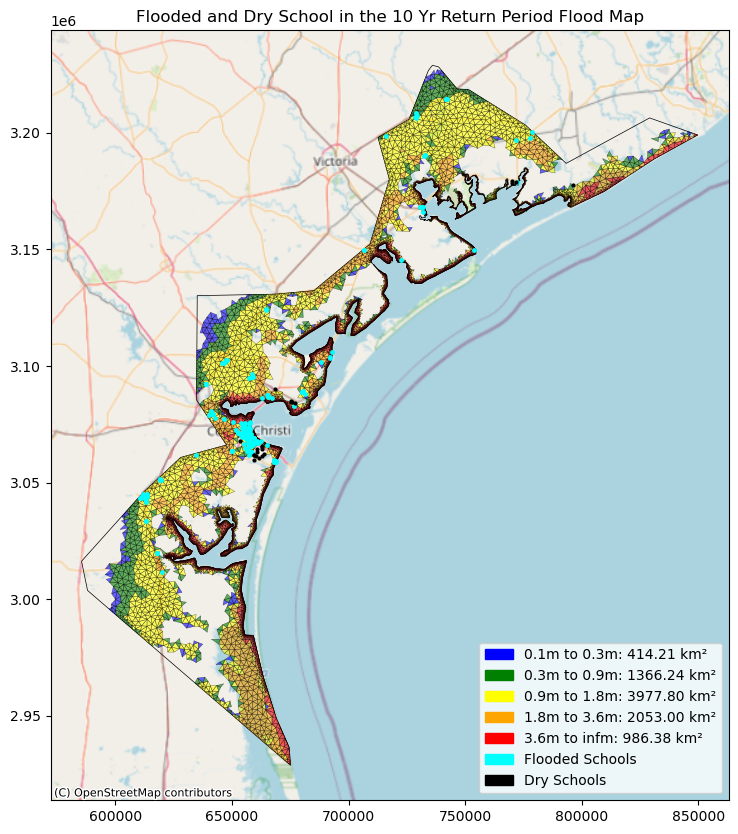

Depth range 0.1m to 0.3m: 414.21 square kilometers
Depth range 0.3m to 0.9m: 1366.24 square kilometers
Depth range 0.9m to 1.8m: 3977.80 square kilometers
Depth range 1.8m to 3.6m: 2053.00 square kilometers
Depth range 3.6m to infm: 986.38 square kilometers


In [22]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx
import folium

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\5-yr return period storm CC.m21fm - Result Files\5-yr_CC_stat_coupled.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)

# Load school shapefile and set the same CRS (EPSG:32614)
shape_path2 = r"D:\Phd Research\Critical Infrastructure\Shape file\Schools2019to2020_372503062685561240.zip"
shape_path3 = r"D:\Phd Research\Critical Infrastructure\Shape file\National_Shelter_System_Facilities.zip"
shape_path4 = r"D:\Phd Research\Critical Infrastructure\Shape file\Hospitals.zip"
shape_path5 = r"D:\Phd Research\Critical Infrastructure\Shape file\Fire_and_Emergency_Medical_Service_(EMS)_Stations.zip"
school_point = gpd.read_file(shape_path2).to_crs(32614)
school_intersect = gpd.overlay(school_point, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"  # Ensure CRS matches
    )
    
    # Clip the polygons with the land boundary shapefile
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Check if schools fall inside the flooded areas using explicit spatial checks
flooded_schools = []
dry_schools = []

for school in school_intersect.itertuples():
    is_flooded = False
    for flooded_area in flooded_polygons_by_range:
        if not flooded_area.empty:
            if flooded_area.contains(school.geometry).any():  # Explicit containment check
                is_flooded = True
                break
    if is_flooded:
        flooded_schools.append(school.geometry)
    else:
        dry_schools.append(school.geometry)

# Convert lists to GeoDataFrames for plotting
flooded_schools_gdf = gpd.GeoDataFrame(geometry=flooded_schools, crs="EPSG:32614")
dry_schools_gdf = gpd.GeoDataFrame(geometry=dry_schools, crs="EPSG:32614")

# Plotting with Basemap and classification
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot flooded and dry schools
flooded_schools_gdf.plot(ax=ax, color='cyan', marker='o', label='Flooded Schools', markersize=6, zorder=5)
dry_schools_gdf.plot(ax=ax, color='black', marker='o', label='Dry Schools', markersize=4, zorder=5)

# Plot each depth range with a different color
for polygons, color in zip(flooded_polygons_by_range, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='black', linewidth=0.3)

# Add basemap
ctx.add_basemap(ax, crs=land_boundary.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
] + [
    mpatches.Patch(color='cyan', label='Flooded Schools'),
    mpatches.Patch(color='black', label='Dry Schools')
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flooded and Dry School in the 10 Yr Return Period Flood Map')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")


In [23]:
num_flooded_schools = len(flooded_schools_gdf)
num_dry_schools = len(dry_schools_gdf)
total_schools = len(school_intersect)

# Calculate the percentages
percent_flooded = (num_flooded_schools / total_schools) * 100
percent_dry = (num_dry_schools / total_schools) * 100

# Print the number and percentage of flooded and dry schools
print(f"Number of flooded schools: {num_flooded_schools}")
print(f"Number of dry schools: {num_dry_schools}")
print(f"Percentage of flooded schools: {percent_flooded:.2f}%")
print(f"Percentage of dry schools: {percent_dry:.2f}%")

Number of flooded schools: 149
Number of dry schools: 22
Percentage of flooded schools: 87.13%
Percentage of dry schools: 12.87%


In [28]:
k = school_intersect.itertuples()


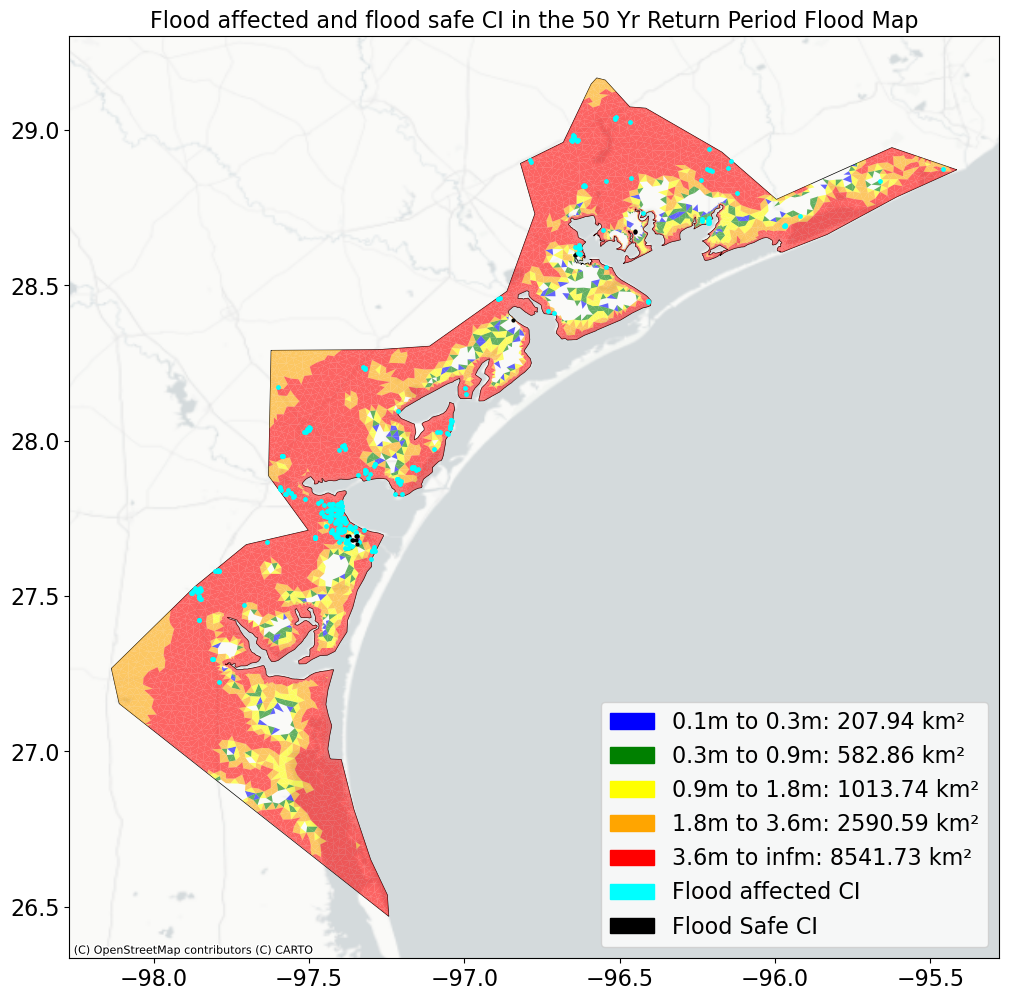

Depth range 0.1m to 0.3m: 207.94 square kilometers
Depth range 0.3m to 0.9m: 582.86 square kilometers
Depth range 0.9m to 1.8m: 1013.74 square kilometers
Depth range 1.8m to 3.6m: 2590.59 square kilometers
Depth range 3.6m to infm: 8541.73 square kilometers


In [56]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx
import folium

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the land boundary shapefile and ensure it's in UTM (EPSG:32614)
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path).to_crs("EPSG:32614")

# Load other shapefiles and convert to the same UTM CRS
shape_path2 = r"D:\Phd Research\Critical Infrastructure\Shape file\Schools2019to2020_372503062685561240.zip"
shape_path3 = r"D:\Phd Research\Critical Infrastructure\Shape file\National_Shelter_System_Facilities.zip"
shape_path4 = r"D:\Phd Research\Critical Infrastructure\Shape file\Hospitals.zip"
shape_path5 = r"D:\Phd Research\Critical Infrastructure\Shape file\Fire_and_Emergency_Medical_Service_(EMS)_Stations.zip"

school_point = gpd.read_file(shape_path2).to_crs("EPSG:32614")
shelter_point = gpd.read_file(shape_path3).to_crs("EPSG:32614")
hospital_point = gpd.read_file(shape_path4).to_crs("EPSG:32614")
fire_station_point = gpd.read_file(shape_path5).to_crs("EPSG:32614")

# Intersect schools with land boundary
school_intersect = gpd.overlay(school_point, land_boundary, how='intersection')
shelter_intersect = gpd.overlay(shelter_point, land_boundary, how='intersection')
hospital_intersect = gpd.overlay(hospital_point, land_boundary, how='intersection')
fire_station_intersect = gpd.overlay(fire_station_point, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons in EPSG:32614
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"
    )
    
    # Clip the polygons with the land boundary shapefile
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection', keep_geom_type=False)
    
    # Calculate the total area for this depth range (convert to square kilometers)
    total_area = flooded_area_clipped.area.sum() / 1e6  
    total_area_by_range.append(total_area)
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Function to check if points fall within flooded areas
def check_flooded_infrastructure(infrastructure_gdf, flooded_polygons_by_range):
    flooded_points = []
    dry_points = []
    
    for infra in infrastructure_gdf.itertuples():
        is_flooded = False
        for flooded_area in flooded_polygons_by_range:
            if not flooded_area.empty and flooded_area.contains(infra.geometry).any():
                is_flooded = True
                break
        if is_flooded:
            flooded_points.append(infra.geometry)
        else:
            dry_points.append(infra.geometry)
    
    flooded_gdf = gpd.GeoDataFrame(geometry=flooded_points, crs="EPSG:32614")
    dry_gdf = gpd.GeoDataFrame(geometry=dry_points, crs="EPSG:32614")
    return flooded_gdf, dry_gdf

# Check flooded status for each infrastructure type
flooded_schools_gdf, dry_schools_gdf = check_flooded_infrastructure(school_intersect, flooded_polygons_by_range)
flooded_shelters_gdf, dry_shelters_gdf = check_flooded_infrastructure(shelter_intersect, flooded_polygons_by_range)
flooded_hospitals_gdf, dry_hospitals_gdf = check_flooded_infrastructure(hospital_intersect, flooded_polygons_by_range)
flooded_fire_stations_gdf, dry_fire_stations_gdf = check_flooded_infrastructure(fire_station_intersect, flooded_polygons_by_range)

# Convert all GeoDataFrames to EPSG:4326
land_boundary = land_boundary.to_crs("EPSG:4326")
for i in range(len(flooded_polygons_by_range)):
    flooded_polygons_by_range[i] = flooded_polygons_by_range[i].to_crs("EPSG:4326")

flooded_schools_gdf = flooded_schools_gdf.to_crs("EPSG:4326")
dry_schools_gdf = dry_schools_gdf.to_crs("EPSG:4326")
flooded_shelters_gdf = flooded_shelters_gdf.to_crs("EPSG:4326")
dry_shelters_gdf = dry_shelters_gdf.to_crs("EPSG:4326")
flooded_hospitals_gdf = flooded_hospitals_gdf.to_crs("EPSG:4326")
dry_hospitals_gdf = dry_hospitals_gdf.to_crs("EPSG:4326")
flooded_fire_stations_gdf = flooded_fire_stations_gdf.to_crs("EPSG:4326")
dry_fire_stations_gdf = dry_fire_stations_gdf.to_crs("EPSG:4326")

# Plotting with Basemap in Lat/Lon (EPSG:4326)
fig, ax = plt.subplots(figsize=(12, 12))
land_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot each depth range with a different color
for polygons, color in zip(flooded_polygons_by_range, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')

# Plot flooded and dry infrastructure
flooded_schools_gdf.plot(ax=ax, color='cyan', marker='o', label='Flooded Schools', markersize=6, zorder=5)
dry_schools_gdf.plot(ax=ax, color='black', marker='o', label='Dry Schools', markersize=4, zorder=5)
flooded_shelters_gdf.plot(ax=ax, color='cyan', marker='o', label='Flooded Shelters', markersize=6, zorder=5)
dry_shelters_gdf.plot(ax=ax, color='black', marker='o', label='Dry Shelters', markersize=4, zorder=5)
flooded_hospitals_gdf.plot(ax=ax, color='cyan', marker='o', label='Flooded Hospitals', markersize=6, zorder=5)
dry_hospitals_gdf.plot(ax=ax, color='black', marker='o', label='Dry Hospitals', markersize=4, zorder=5)
flooded_fire_stations_gdf.plot(ax=ax, color='cyan', marker='o', label='Flooded Fire Stations', markersize=6, zorder=5)
dry_fire_stations_gdf.plot(ax=ax, color='black', marker='o', label='Dry Fire Stations', markersize=4, zorder=5)

# Add basemap
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Stamen.Watercolor)
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldImagery)
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Stamen.TonerLite)
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenTopoMap)
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels)
# ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter)
# ctx.add_basemap(ax, source=ctx.providers.Esri.NatGeoWorldMap)
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTerrain)
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldStreetMap)
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTopoMap)


# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
] + [
    mpatches.Patch(color='cyan', label='Flood affected CI'),
    mpatches.Patch(color='black', label='Flood Safe CI'),
   ]
ax.legend(handles=legend_patches, loc='lower right', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)  # Increase axis tick labels size
# ax.set_xlabel('Longitude', fontsize=14)  # X-axis label size
# ax.set_ylabel('Latitude', fontsize=14)  # Y-axis label size

plt.title('Flood affected and flood safe CI in the 50 Yr Return Period Flood Map', fontsize=16)
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")



In [17]:
# Schools
num_flooded_schools = len(flooded_schools_gdf)
num_dry_schools = len(dry_schools_gdf)
total_schools = len(school_intersect)
percent_flooded_schools = (num_flooded_schools / total_schools) * 100
percent_dry_schools = (num_dry_schools / total_schools) * 100

print(f"Number of flooded schools: {num_flooded_schools}")
print(f"Number of dry schools: {num_dry_schools}")
print(f"Percentage of flooded schools: {percent_flooded_schools:.2f}%")
print(f"Percentage of dry schools: {percent_dry_schools:.2f}%\n")

# Shelters
num_flooded_shelters = len(flooded_shelters_gdf)
num_dry_shelters = len(dry_shelters_gdf)
total_shelters = len(shelter_intersect)
percent_flooded_shelters = (num_flooded_shelters / total_shelters) * 100
percent_dry_shelters = (num_dry_shelters / total_shelters) * 100

print(f"Number of flooded shelters: {num_flooded_shelters}")
print(f"Number of dry shelters: {num_dry_shelters}")
print(f"Percentage of flooded shelters: {percent_flooded_shelters:.2f}%")
print(f"Percentage of dry shelters: {percent_dry_shelters:.2f}%\n")

# Hospitals
num_flooded_hospitals = len(flooded_hospitals_gdf)
num_dry_hospitals = len(dry_hospitals_gdf)
total_hospitals = len(hospital_intersect)
percent_flooded_hospitals = (num_flooded_hospitals / total_hospitals) * 100
percent_dry_hospitals = (num_dry_hospitals / total_hospitals) * 100

print(f"Number of flooded hospitals: {num_flooded_hospitals}")
print(f"Number of dry hospitals: {num_dry_hospitals}")
print(f"Percentage of flooded hospitals: {percent_flooded_hospitals:.2f}%")
print(f"Percentage of dry hospitals: {percent_dry_hospitals:.2f}%\n")

# Fire Stations
num_flooded_fire_stations = len(flooded_fire_stations_gdf)
num_dry_fire_stations = len(dry_fire_stations_gdf)
total_fire_stations = len(fire_station_intersect)
percent_flooded_fire_stations = (num_flooded_fire_stations / total_fire_stations) * 100
percent_dry_fire_stations = (num_dry_fire_stations / total_fire_stations) * 100

print(f"Number of flooded fire stations: {num_flooded_fire_stations}")
print(f"Number of dry fire stations: {num_dry_fire_stations}")
print(f"Percentage of flooded fire stations: {percent_flooded_fire_stations:.2f}%")
print(f"Percentage of dry fire stations: {percent_dry_fire_stations:.2f}%")


Number of flooded schools: 168
Number of dry schools: 3
Percentage of flooded schools: 98.25%
Percentage of dry schools: 1.75%

Number of flooded shelters: 43
Number of dry shelters: 4
Percentage of flooded shelters: 91.49%
Percentage of dry shelters: 8.51%

Number of flooded hospitals: 19
Number of dry hospitals: 3
Percentage of flooded hospitals: 86.36%
Percentage of dry hospitals: 13.64%

Number of flooded fire stations: 58
Number of dry fire stations: 4
Percentage of flooded fire stations: 93.55%
Percentage of dry fire stations: 6.45%


In [5]:
!pip install folium


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/110.9 kB ? eta -:--:--
   --- ------------------------------------ 10.2/110.9 kB ? eta -:--:--
   ---------------------------------------- 110.9/110.9 kB 1.3 MB/s eta 0:00:00


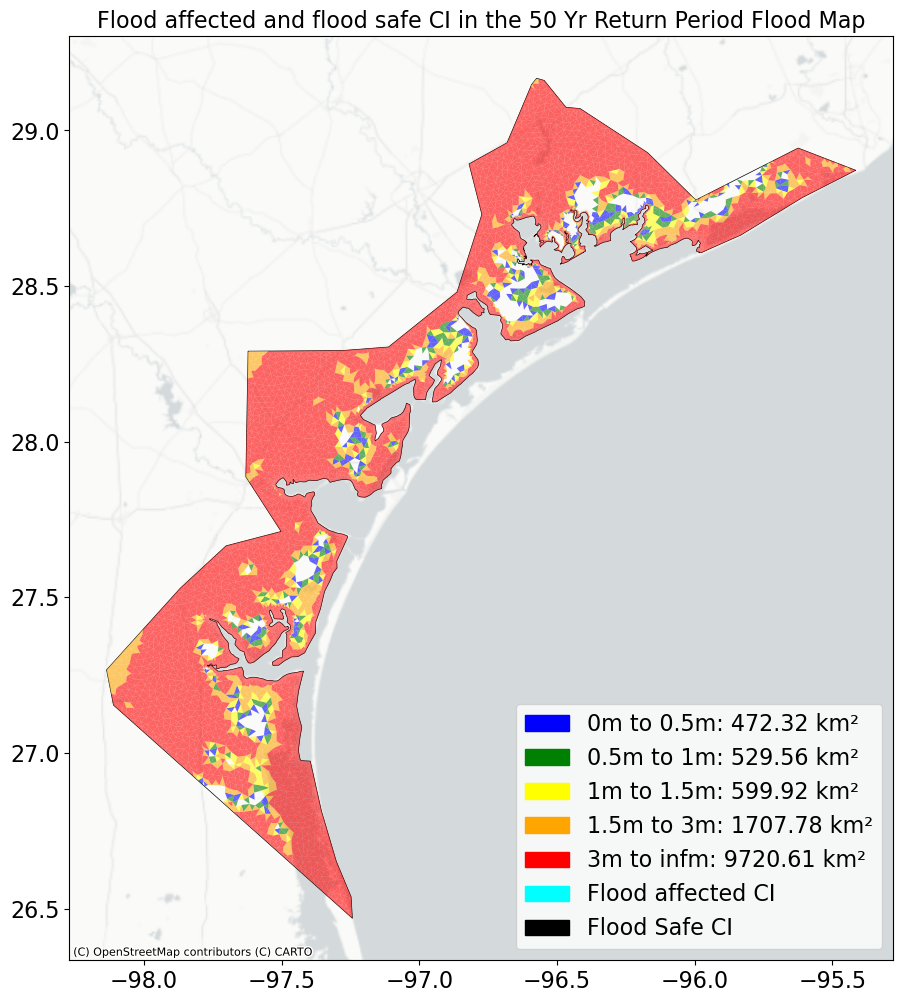

Depth range 0m to 0.5m: 472.32 square kilometers
Depth range 0.5m to 1m: 529.56 square kilometers
Depth range 1m to 1.5m: 599.92 square kilometers
Depth range 1.5m to 3m: 1707.78 square kilometers
Depth range 3m to infm: 9720.61 square kilometers


In [7]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx
import folium

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the land boundary shapefile and ensure it's in UTM (EPSG:32614)
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path).to_crs("EPSG:32614")


# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0, 0.5),
    (0.5, 1),
    (1, 1.5),
    (1.5, 3),
    (3, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons in EPSG:32614
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"
    )
    
    # Clip the polygons with the land boundary shapefile
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection', keep_geom_type=False)
    
    # Calculate the total area for this depth range (convert to square kilometers)
    total_area = flooded_area_clipped.area.sum() / 1e6  
    total_area_by_range.append(total_area)
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Function to check if points fall within flooded areas
def check_flooded_infrastructure(infrastructure_gdf, flooded_polygons_by_range):
    flooded_points = []
    dry_points = []
    
    for infra in infrastructure_gdf.itertuples():
        is_flooded = False
        for flooded_area in flooded_polygons_by_range:
            if not flooded_area.empty and flooded_area.contains(infra.geometry).any():
                is_flooded = True
                break
        if is_flooded:
            flooded_points.append(infra.geometry)
        else:
            dry_points.append(infra.geometry)
    
    flooded_gdf = gpd.GeoDataFrame(geometry=flooded_points, crs="EPSG:32614")
    dry_gdf = gpd.GeoDataFrame(geometry=dry_points, crs="EPSG:32614")
    return flooded_gdf, dry_gdf



# Convert all GeoDataFrames to EPSG:4326
land_boundary = land_boundary.to_crs("EPSG:4326")
for i in range(len(flooded_polygons_by_range)):
    flooded_polygons_by_range[i] = flooded_polygons_by_range[i].to_crs("EPSG:4326")


# Plotting with Basemap in Lat/Lon (EPSG:4326)
fig, ax = plt.subplots(figsize=(12, 12))
land_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot each depth range with a different color
for polygons, color in zip(flooded_polygons_by_range, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')


# Add basemap
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Stamen.Watercolor)
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldImagery)
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Stamen.TonerLite)
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenTopoMap)
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels)
# ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter)
# ctx.add_basemap(ax, source=ctx.providers.Esri.NatGeoWorldMap)
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTerrain)
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldStreetMap)
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTopoMap)


# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
] + [
    mpatches.Patch(color='cyan', label='Flood affected CI'),
    mpatches.Patch(color='black', label='Flood Safe CI'),
   ]
ax.legend(handles=legend_patches, loc='lower right', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)  # Increase axis tick labels size
# ax.set_xlabel('Longitude', fontsize=14)  # X-axis label size
# ax.set_ylabel('Latitude', fontsize=14)  # Y-axis label size

plt.title('Flood affected and flood safe CI in the 50 Yr Return Period Flood Map', fontsize=16)
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")
